# ODTbrain
Provides image reconstruction algorithms for Optical Diffraction Tomography. By Paul Muller, Mirjam Schurmann, and Jochen Guck.
- [1] ODTbrain documentation: https://odtbrain.readthedocs.io/en/stable/ex3d.html
- [2] ODTbrain repository: https://github.com/RI-imaging/ODTbrain
- [3] Optical Diffraction Tomography for Single Cells: https://nbn-resolving.org/urn:nbn:de:bsz:14-qucosa-202261
- [4] Diffraction microtomography with sample rotation: influence of a missing apple core in the recorded frequency space: https://doi.org/10.2478/s11534-008-0154-6
- [5] Cellsino library for generating sinograms: https://cellsino.readthedocs.io/en/stable/sec_examples.html#example-simple-cell

In [41]:
#=-----------------------------------------------------------------------=#

In [ ]:
%%bash
pip install odtbrain  # dense diffraction tomography
pip install cellsino  # generating sinograms

## 3D example - Missing apple core correction
The missing apple core is a phenomenon in diffraction tomography that is a result of the fact the the Fourier space is not filled completely when the sample is rotated only about a single axis. The resulting artifacts include ringing and blurring in the reconstruction parallel to the original rotation axis. By enforcing constraints (refractive index real-valued and larger than the surrounding medium), these artifacts can be attenuated.

This example generates an artificial sinogram using the Python library Cellsino. The sinogram is then reconstructed with the backpropagation algorithm and the missing apple core correction is applied. The example parameters were adapted from [4] and [5].

In [1]:
import numpy as np
np.set_printoptions(precision=2, suppress=True, edgeitems=2, linewidth=75, threshold=100)
import matplotlib.pylab as plt

In [3]:
import odtbrain as odt

In [4]:
import cellsino

## Python 250x250x250

In [21]:
# number of sinogram angles
num_ang = 160
# sinogram acquisition angles
angles = np.linspace(0, 2*np.pi, num_ang, endpoint=False)
# detector grid size
grid_size = (250, 250)
# vacuum wavelength [m]
wavelength = 550e-9
# pixel size [m]
pixel_size = 0.08e-6
# refractive index of the surrounding medium
medium_index = 1.335  # water

# initialize cell phantom
phantom = cellsino.phantoms.SimpleCell()

# initialize sinogram with geometric parameters
sino = cellsino.Sinogram(phantom=phantom,
                         wavelength=wavelength,
                         pixel_size=pixel_size,
                         grid_size=grid_size)

# compute sinogram (field according to Rytov approximation and fluorescence)
sino = sino.compute(angles=angles, propagator="rytov", mode="field")

# reconstruction of refractive index
sino_rytov = odt.sinogram_as_rytov(sino)
f = odt.backpropagate_3d(uSin=sino_rytov,
                         angles=angles,
                         res=wavelength/pixel_size,
                         nm=medium_index)

ri = odt.odt_to_ri(f=f,
                   res=wavelength/pixel_size,
                   nm=medium_index)

# apple core correction
fc = odt.apple.correct(f=f,
                       res=wavelength/pixel_size,
                       nm=medium_index,
                       method="sh")

ric = odt.odt_to_ri(f=fc,
                    res=wavelength/pixel_size,
                    nm=medium_index)

In [50]:
print('ri: shape=',ri.shape,', dtype=', ri.dtype,', size=',ri.size)
print('ric: shape=',ric.shape,', dtype=', ric.dtype,', size=',ric.size)

ri: shape= (250, 250, 250) , dtype= complex128 , size= 15625000
ric: shape= (250, 250, 250) , dtype= complex64 , size= 15625000


In [29]:
np.save('data/ri', ri)
np.save('data/ric', ric)

In [30]:
ri.T.tofile('data/ri.bin')
ric.T.tofile('data/ric.bin')

In [15]:
ri = np.fromfile("data/ri.bin", dtype=np.complex128).reshape((250,250,250))

In [16]:
print('ri: shape =', ri.shape, ', size =', ri.size)
print('checksum in : {:.4f}'.format(np.sum(ri)))

ri: shape = (250, 250, 250) , size = 15625000
checksum in : 20888865.4801-0.7945j


In [17]:
f250 = np.fft.fftn(ri)

In [18]:
print('f250 : shape =', f250.shape, ', size =', f250.size)
print('checksum out: {:.4f}'.format(np.sum(f250)))

f250 : shape = (250, 250, 250) , size = 15625000
checksum out: 20858577.3057-16.0384j


In [19]:
np.save('data/fft', f250)

In [23]:
# log-scaled power spectra
ft = np.log(1 + np.abs(np.fft.fftshift(np.fft.fftn(ri))))
ftc = np.log(1 + np.abs(np.fft.fftshift(np.fft.fftn(ric))))

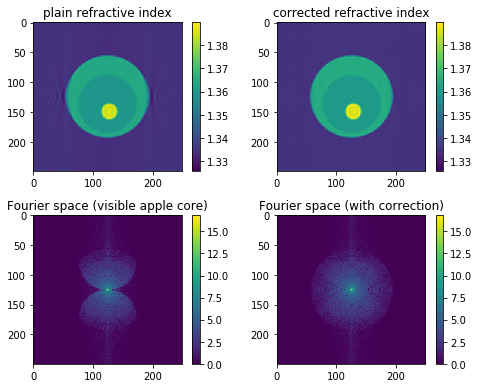

In [24]:
# plotting
idx = ri.shape[2] // 2

plt.figure(figsize=(7, 5.5))

plotkwri = {"vmax": ri.real.max(),
            "vmin": ri.real.min(),
            "interpolation": "none",
            }

plotkwft = {"vmax": ft.max(),
            "vmin": 0,
            "interpolation": "none",
            }

ax1 = plt.subplot(221, title="plain refractive index")
mapper = ax1.imshow(ri[:, :, idx].real, **plotkwri)
plt.colorbar(mappable=mapper, ax=ax1)

ax2 = plt.subplot(222, title="corrected refractive index")
mapper = ax2.imshow(ric[:, :, idx].real, **plotkwri)
plt.colorbar(mappable=mapper, ax=ax2)

ax3 = plt.subplot(223, title="Fourier space (visible apple core)")
mapper = ax3.imshow(ft[:, :, idx], **plotkwft)
plt.colorbar(mappable=mapper, ax=ax3)

ax4 = plt.subplot(224, title="Fourier space (with correction)")
mapper = ax4.imshow(ftc[:, :, idx], **plotkwft)
plt.colorbar(mappable=mapper, ax=ax4)

plt.tight_layout()  # Adjust the padding between and around subplots.
plt.show()

## Fortran 250x250x250

In [22]:
%%writefile test19.f90
program main
    use, intrinsic :: iso_c_binding
    implicit none
    include "fftw3.f03"
    integer :: i, j, k
    integer, parameter :: N = 250, M = 250, L = 250
    type(C_PTR) :: plan, cdata
    complex(C_DOUBLE_COMPLEX), pointer :: data(:,:,:)
    complex(C_DOUBLE_COMPLEX) :: s    ! checksum

    ! in-place transform (note dimension reversal)
    cdata = fftw_alloc_complex(int(L * M * N, C_SIZE_T))
    call c_f_pointer(cdata, data, [L, M, N])

    ! create plan for in-place forward DFT (note dimension reversal)
    plan = fftw_plan_dft_3d(N, M, L, data, data, &
                            FFTW_FORWARD, FFTW_ESTIMATE)

    ! initialize data
    open(0, file='data/ri.bin', access='stream', form='unformatted')
    read(0) data
    close(0)

    write(*,*) shape(data)

    s = sum(data)    ! checksum
    write(*, "('checksum in:  '*(f0.4spf0.4'j':x))") s
    
    !compute transform
    call fftw_execute_dft(plan, data, data)
        
    s = sum(data)    ! checksum
    write(*, "('checksum out: '*(f0.4spf0.4'j':x))") s
    
!    write(*,*)'out:'; do k = 100, 102; do j = 100, 102
!        write(*,"(*('('f0.2','f5.2')':x))") data(k,j,100:102)
!    end do; write(*,*); end do


end

Overwriting test19.f90


In [23]:
! gfortran test19.f90 \
-L $(pwd)/lo/lib -l fftw3 -l m -I $(pwd)/lo/include \
-fcheck=all -ffpe-trap= -w -fno-backtrace && ./a.out

         250         250         250
checksum in:  20888865.4801-.7945j
checksum out: 20858577.3057-16.0384j


## Show 3x3x3 data structure

In [4]:
num_ang = 160
angles = np.linspace(0, 2*np.pi, num_ang, endpoint=False)
grid_size = (3, 3)
wavelength = 550e-9
pixel_size = 0.08e-6
medium_index = 1.335
phantom = cellsino.phantoms.SimpleCell()
sino = cellsino.Sinogram(phantom=phantom,
                         wavelength=wavelength,
                         pixel_size=pixel_size,
                         grid_size=grid_size)
sino = sino.compute(angles=angles, propagator="rytov", mode="field")
sino_rytov = odt.sinogram_as_rytov(sino)
f = odt.backpropagate_3d(uSin=sino_rytov,
                         angles=angles,
                         res=wavelength/pixel_size,
                         nm=medium_index)
ri = odt.odt_to_ri(f=f,
                   res=wavelength/pixel_size,
                   nm=medium_index)
fft3d = np.fft.fftn(ri)

In [5]:
np.set_printoptions(precision=2, suppress=True, edgeitems=2)
print('ri: shape=',ri.shape,', dtype=', ri.dtype,', size=',ri.size)
print('checksum: {:.4f}'.format(np.sum(ri)))
print(ri)
print('fft3d: shape=',fft3d.shape,', dtype=', fft3d.dtype,', size=',fft3d.size)
print('checksum: {:.4f}'.format(np.sum(fft3d)))
print(fft3d)

ri: shape= (3, 3, 3) , dtype= complex128 , size= 27
checksum: 36.5118-0.0638j
[[[1.34-0.j 1.36-0.j 1.34-0.j]
  [1.34-0.j 1.36-0.j 1.34-0.j]
  [1.34-0.j 1.36-0.j 1.34-0.j]]

 [[1.36-0.j 1.37-0.j 1.36-0.j]
  [1.36-0.j 1.38-0.j 1.36-0.j]
  [1.36-0.j 1.37-0.j 1.36-0.j]]

 [[1.34-0.j 1.36-0.j 1.34-0.j]
  [1.34-0.j 1.36-0.j 1.34-0.j]
  [1.34-0.j 1.36-0.j 1.34-0.j]]]
fft3d: shape= (3, 3, 3) , dtype= complex128 , size= 27
checksum: 36.0601-0.0029j
[[[36.51-0.06j -0.13-0.16j -0.08+0.19j]
  [-0.  -0.j   -0.  +0.j    0.  -0.j  ]
  [-0.  +0.j    0.  -0.j   -0.  -0.j  ]]

 [[-0.12-0.16j  0.02-0.05j -0.05+0.01j]
  [-0.  +0.j   -0.  +0.j    0.  +0.j  ]
  [ 0.  -0.j    0.  +0.j    0.  -0.j  ]]

 [[-0.08+0.19j -0.05+0.01j  0.04+0.04j]
  [ 0.  -0.j    0.  +0.j    0.  -0.j  ]
  [-0.  -0.j    0.  -0.j   -0.  +0.j  ]]]


In [6]:
ri.T.tofile('data/ri3.bin')

## Fortran 3x3x3

In [14]:
%%writefile test18.f90
program main
    use, intrinsic :: iso_c_binding
    implicit none
    include "fftw3.f03"
    integer :: j, k           
    integer, parameter :: L = 3, M = 3, N = 3
    type(C_PTR) :: plan, cdata
    complex(C_DOUBLE_COMPLEX), pointer :: data(:,:,:)
    complex(C_DOUBLE_COMPLEX) :: s    ! checksum

    ! in-place transform (note dimension reversal)
    cdata = fftw_alloc_complex(int(L * M * N, C_SIZE_T))
    call c_f_pointer(cdata, data, [L, M, N])

    ! create plan for in-place forward DFT (note dimension reversal)
    plan = fftw_plan_dft_3d(N, M, L, data, data, &
                            FFTW_FORWARD, FFTW_ESTIMATE)

    ! initialize data
    open(0, file='data/ri3.bin', access='stream', form='unformatted')
    read(0) data
    close(0)

    write(*,*)'in:'; do k = 1, N; do j = 1, N
        write(*,"(*('('f5.2','f5.2')':x))") data(k,j,:)
    end do; write(*,*); end do
    
    !compute transform
    call fftw_execute_dft(plan, data, data)
    
    write(*,*)'out:'; do k = 1, N; do j = 1, N
        write(*,"(*('('f5.2','f5.2')':x))") data(k,j,:)
    end do; write(*,*); end do
    
    s = sum(data)    ! checksum
    write(*, "('checksum: '*(f0.4spf0.4'j':x))") s

end

Overwriting test18.f90


In [15]:
! gfortran test18.f90 \
-L $(pwd)/lo/lib -l fftw3 -l m -I $(pwd)/lo/include \
-fcheck=all -ffpe-trap= -w -fno-backtrace && ./a.out

 in:
( 1.34,-0.00) ( 1.36,-0.00) ( 1.34,-0.00)
( 1.34,-0.00) ( 1.36,-0.00) ( 1.34,-0.00)
( 1.34,-0.00) ( 1.36,-0.00) ( 1.34,-0.00)

( 1.36,-0.00) ( 1.37,-0.00) ( 1.36,-0.00)
( 1.36,-0.00) ( 1.38,-0.00) ( 1.36,-0.00)
( 1.36,-0.00) ( 1.37,-0.00) ( 1.36,-0.00)

( 1.34,-0.00) ( 1.36,-0.00) ( 1.34,-0.00)
( 1.34,-0.00) ( 1.36,-0.00) ( 1.34,-0.00)
( 1.34,-0.00) ( 1.36,-0.00) ( 1.34,-0.00)

 out:
(36.51,-0.06) (-0.13,-0.16) (-0.08, 0.19)
(-0.00,-0.00) (-0.00, 0.00) ( 0.00,-0.00)
(-0.00, 0.00) ( 0.00,-0.00) (-0.00,-0.00)

(-0.12,-0.16) ( 0.02,-0.05) (-0.05, 0.01)
(-0.00, 0.00) (-0.00, 0.00) ( 0.00, 0.00)
( 0.00,-0.00) ( 0.00, 0.00) ( 0.00,-0.00)

(-0.08, 0.19) (-0.05, 0.01) ( 0.04, 0.04)
( 0.00,-0.00) ( 0.00, 0.00) ( 0.00,-0.00)
(-0.00,-0.00) ( 0.00,-0.00) (-0.00, 0.00)

checksum: 36.0601-.0029j


## Python 6x6x6

In [9]:
num_ang = 160
angles = np.linspace(0, 2*np.pi, num_ang, endpoint=False)
grid_size = (6, 6)
wavelength = 550e-9
pixel_size = 0.08e-6
medium_index = 1.335
phantom = cellsino.phantoms.SimpleCell()
sino = cellsino.Sinogram(phantom=phantom,
                         wavelength=wavelength,
                         pixel_size=pixel_size,
                         grid_size=grid_size)
sino = sino.compute(angles=angles, propagator="rytov", mode="field")
sino_rytov = odt.sinogram_as_rytov(sino)
f = odt.backpropagate_3d(uSin=sino_rytov,
                         angles=angles,
                         res=wavelength/pixel_size,
                         nm=medium_index)
ri = odt.odt_to_ri(f=f,
                   res=wavelength/pixel_size,
                   nm=medium_index)

In [10]:
ri.T.tofile('data/ri6.bin')
print('ri: shape=',ri.shape,', dtype=', ri.dtype,', size=',ri.size)
print('checksum: {:.4f}'.format(np.sum(ri)))

ri: shape= (6, 6, 6) , dtype= complex128 , size= 216
checksum: 294.3947-0.3028j


In [11]:
ri

array([[[1.34+0.j  , 1.34-0.j  , ..., 1.34-0.j  , 1.34+0.j  ],
        [1.34-0.j  , 1.34-0.j  , ..., 1.34-0.j  , 1.34-0.j  ],
        ...,
        [1.34-0.j  , 1.34-0.j  , ..., 1.34-0.j  , 1.34-0.j  ],
        [1.34+0.j  , 1.34-0.j  , ..., 1.34-0.j  , 1.34+0.j  ]],

       [[1.34-0.j  , 1.36-0.j  , ..., 1.37-0.j  , 1.34-0.j  ],
        [1.34-0.j  , 1.37-0.j  , ..., 1.37-0.j  , 1.34-0.j  ],
        ...,
        [1.34-0.j  , 1.37-0.j  , ..., 1.37-0.j  , 1.34-0.j  ],
        [1.34-0.j  , 1.36-0.j  , ..., 1.36-0.j  , 1.34-0.j  ]],

       ...,

       [[1.34-0.j  , 1.37-0.j  , ..., 1.35-0.j  , 1.34-0.j  ],
        [1.34-0.j  , 1.37-0.j  , ..., 1.35-0.01j, 1.34-0.j  ],
        ...,
        [1.34-0.j  , 1.37-0.j  , ..., 1.35-0.01j, 1.34-0.j  ],
        [1.34+0.j  , 1.37-0.j  , ..., 1.34-0.j  , 1.34-0.j  ]],

       [[1.34+0.j  , 1.34-0.j  , ..., 1.34-0.j  , 1.34+0.j  ],
        [1.34+0.j  , 1.34-0.j  , ..., 1.34-0.j  , 1.34-0.j  ],
        ...,
        [1.34+0.j  , 1.34-0.j  , ..., 1.34-0.j 

In [12]:
fft3d = np.fft.fftn(ri)
fft3d

array([[[294.39-0.3j ,  -2.05-1.62j, ...,  -0.06+0.15j,  -2.13+1.62j],
        [ -0.59-0.14j,   0.23+0.22j, ...,   0.02-0.j  ,   0.23-0.05j],
        ...,
        [ -0.01+0.08j,   0.  -0.02j, ...,  -0.  +0.j  ,  -0.01-0.05j],
        [ -0.4 +0.48j,   0.24-0.11j, ...,  -0.  -0.01j,   0.1 -0.28j]],

       [[ -2.1 -1.54j,   0.26+1.25j, ...,   0.14-0.12j,   0.78+0.14j],
        [  0.21+0.18j,  -0.04-0.13j, ...,  -0.02-0.01j,  -0.11-0.06j],
        ...,
        [  0.02-0.03j,  -0.01-0.j  , ...,  -0.  -0.j  ,   0.  +0.01j],
        [  0.27-0.11j,  -0.11-0.02j, ...,  -0.01-0.j  ,  -0.08+0.07j]],

       ...,

       [[ -0.03+0.18j,   0.12-0.12j, ...,   0.06+0.15j,  -0.14-0.08j],
        [ -0.  -0.j  ,  -0.02-0.02j, ...,   0.02-0.02j,  -0.01+0.02j],
        ...,
        [ -0.  -0.01j,   0.  -0.j  , ...,   0.  -0.j  ,  -0.  -0.j  ],
        [  0.01-0.03j,  -0.  +0.j  , ...,   0.02-0.02j,   0.01+0.j  ]],

       [[ -2.15+1.54j,   0.79+0.07j, ...,  -0.18-0.09j,   0.6 -1.07j],
        [  0.26-0.0

In [13]:
print('fft3d: shape=',fft3d.shape,', dtype=', fft3d.dtype,', size=',fft3d.size)
print('checksum: {:.4f}'.format(np.sum(fft3d)))

fft3d: shape= (6, 6, 6) , dtype= complex128 , size= 216
checksum: 288.4236+0.0027j


## Fortran 6x6x6

In [18]:
%%writefile test19.f90
program main
    use, intrinsic :: iso_c_binding
    implicit none
    include "fftw3.f03"
    integer :: i, j, k
    integer, parameter :: N = 6, M = 6, L = 6
    type(C_PTR) :: plan, cdata
    complex(C_DOUBLE_COMPLEX), pointer :: data(:,:,:)
    complex(C_DOUBLE_COMPLEX) :: s    ! checksum

    ! in-place transform (note dimension reversal)
    cdata = fftw_alloc_complex(int(L * M * N, C_SIZE_T))
    call c_f_pointer(cdata, data, [L, M, N])

    ! create plan for in-place forward DFT (note dimension reversal)
    plan = fftw_plan_dft_3d(N, M, L, data, data, &
                            FFTW_FORWARD, FFTW_ESTIMATE)

    ! initialize data
    open(0, file='data/ri6.bin', access='stream', form='unformatted')
    read(0) data
    close(0)

    write(*,*) shape(data)

    s = sum(data)    ! checksum
    write(*, "('checksum in:  '*(f0.4spf0.4'j':x))") s
    
    !compute transform
    call fftw_execute_dft(plan, data, data)
    
    s = sum(data)    ! checksum
    write(*, "('checksum out: '*(f0.4spf0.4'j':x))") s

end

Overwriting test19.f90


In [19]:
! gfortran test19.f90 \
-L $(pwd)/lo/lib -l fftw3 -l m -I $(pwd)/lo/include \
-fcheck=all -ffpe-trap= -w -fno-backtrace && ./a.out

           6           6           6
checksum in:  294.3947-.3028j
checksum out: 288.4236+.0027j


## Python 64x64x64

In [24]:
num_ang = 160
angles = np.linspace(0, 2*np.pi, num_ang, endpoint=False)
grid_size = (64, 64)
wavelength = 550e-9
pixel_size = 0.08e-6
medium_index = 1.335
phantom = cellsino.phantoms.SimpleCell()
sino = cellsino.Sinogram(phantom=phantom,
                         wavelength=wavelength,
                         pixel_size=pixel_size,
                         grid_size=grid_size)
sino = sino.compute(angles=angles, propagator="rytov", mode="field")
sino_rytov = odt.sinogram_as_rytov(sino)
f = odt.backpropagate_3d(uSin=sino_rytov,
                         angles=angles,
                         res=wavelength/pixel_size,
                         nm=medium_index)
ri = odt.odt_to_ri(f=f,
                   res=wavelength/pixel_size,
                   nm=medium_index)

In [25]:
ri.T.tofile('data/ri64.bin')

In [37]:
print('ri: shape=',ri.shape,', dtype=', ri.dtype,', size=',ri.size)
print('checksum in : {:.4f}'.format(np.sum(ri)))

ri: shape= (64, 64, 64) , dtype= complex128 , size= 262144
checksum in : 350801.3209-1.1551j


In [5]:
ri = np.fromfile("data/ri64.bin", dtype=np.complex128).reshape((64,64,64))

In [6]:
print('ri: shape=',ri.shape,', dtype=', ri.dtype,', size=',ri.size)
print('checksum in : {:.4f}'.format(np.sum(ri)))

ri: shape= (64, 64, 64) , dtype= complex128 , size= 262144
checksum in : 350801.3209-1.1551j


In [11]:
f64 = np.fft.fftn(ri)

In [12]:
print('f64: shape=',f64.shape,', dtype=', f64.dtype,', size=',f64.size)
print('checksum out: {:.4f}'.format(np.sum(f64)))

f64: shape= (64, 64, 64) , dtype= complex128 , size= 262144
checksum out: 350008.2341-5.0645j


## Fortran 64x64x64

In [13]:
%%writefile test19.f90
program main
    use, intrinsic :: iso_c_binding
    implicit none
    include "fftw3.f03"
    integer :: i, j, k
    integer, parameter :: N = 64, M = 64, L = 64
    type(C_PTR) :: plan, cdata
    complex(C_DOUBLE_COMPLEX), pointer :: data(:,:,:)
    complex(C_DOUBLE_COMPLEX) :: s    ! checksum

    ! in-place transform (note dimension reversal)
    cdata = fftw_alloc_complex(int(L * M * N, C_SIZE_T))
    call c_f_pointer(cdata, data, [L, M, N])

    ! create plan for in-place forward DFT (note dimension reversal)
    plan = fftw_plan_dft_3d(N, M, L, data, data, &
                            FFTW_FORWARD, FFTW_ESTIMATE)

    ! initialize data
    open(0, file='data/ri64.bin', access='stream', form='unformatted')
    read(0) data
    close(0)

    write(*,*) shape(data)

    s = sum(data)    ! checksum
    write(*, "('checksum in:  '*(f0.4spf0.4'j':x))") s
    
    !compute transform
    call fftw_execute_dft(plan, data, data)
        
    s = sum(data)    ! checksum
    write(*, "('checksum out: '*(f0.4spf0.4'j':x))") s
    
!    write(*,*)'out:'; do k = 50, 52; do j = 50, 52
!        write(*,"(*('('f0.2','f5.2')':x))") data(k,j,50:52)
!    end do; write(*,*); end do


end

Overwriting test19.f90


In [14]:
! gfortran test19.f90 \
-L $(pwd)/lo/lib -l fftw3 -l m -I $(pwd)/lo/include \
-fcheck=all -ffpe-trap= -w -fno-backtrace && ./a.out

          64          64          64
checksum in:  350801.3209-1.1551j
checksum out: 350008.2341-5.0645j


## Check saved data

In [32]:
test1 = np.load('data/ri.npy')

In [53]:
print('test1: shape=',test1.shape,', dtype=', test1.dtype,', size=',test1.size)
print('checksum: {:.4f}'.format(np.sum(test1)))

test1: shape= (250, 250, 250) , dtype= complex128 , size= 15625000
checksum: 20888865.4801-0.7945j


In [42]:
test2 = np.fromfile("data/ri.bin", dtype=np.complex128).reshape((250,250,250))

In [54]:
print('test2: shape=',test2.shape,', dtype=', test2.dtype,', size=',test2.size)
print('checksum: {:.4f}'.format(np.sum(test2)))

test2: shape= (250, 250, 250) , dtype= complex128 , size= 15625000
checksum: 20888865.4801-0.7945j


In [55]:
test3 = np.fft.fftn(test2)

In [56]:
print('test3: shape=',test3.shape,', dtype=', test3.dtype,', size=',test3.size)
print('checksum: {:.4f}'.format(np.sum(test3)))

test3: shape= (250, 250, 250) , dtype= complex128 , size= 15625000
checksum: 20858577.3057-16.0384j
